# Predicting Gross Output When Increasing Compensation

## Cleaning, Combining, and Modifying Data Types

In [717]:
# importing files and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as sfm

sheet_one = pd.read_excel("Business.xlsx", sheet_name = "Table 1")
sheet_two = pd.read_excel("Business.xlsx", sheet_name = "Table 2")
sheet_three = pd.read_excel("Business.xlsx", sheet_name = "Table 3")
sheet_four = pd.read_excel("Business.xlsx", sheet_name = "Table 4")
sheet_five = pd.read_excel("Business.xlsx", sheet_name = "Table 5")
sheet_six = pd.read_excel("Business.xlsx", sheet_name = "Table 6")
sheet_seven = pd.read_excel("Business.xlsx", sheet_name = "Table 7")
sheet_eight = pd.read_excel("Business.xlsx", sheet_name = "Table 8")



In [718]:
# viewing the first sheet to know what to clean
sheet_one.head(7)

,Table 1. Space Economy Real Value Added by Industry,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,[Millions of chained (2017) dollars],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bureau of Economic Analysis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Last updated: March 31, 2025",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,,,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
5,1,Space economy1,101966,111559,113173,121868,123054,122183,119387,122860,118004,111560,115265,115962
6,2,Private industries,79861,89170,90495,98536,99506,98699,95196,96575,92167,85568,87779,86351


In [719]:
# consolidating sheets for unanimous cleaning
sheet_list = [sheet_one, sheet_two, sheet_three, sheet_four, sheet_five, sheet_six, sheet_seven, sheet_eight]
table_measurements = ['Real Value Added', 'Value Added', 'Value Added Price Index', 'Real Gross Output', 'Gross Output', 'Gross Output Price Index', 'Employment', 'Compensation']
copy_list = sheet_list.copy()

for i in range(len(sheet_list)):
    sheet_list[i] = sheet_list[i].loc[4:] # removing info text rows
    sheet_list[i] = sheet_list[i].rename(columns = sheet_list[i].loc[4]) # columns now years
    sheet_list[i] = sheet_list[i].drop(index = 4) # removing years from rows
    sheet_list[i].iloc[:, 1] = sheet_list[i].iloc[:, 1].astype(str).str.replace(r'\d+', '', regex = True) # removing numbers from industries (googled regex)
    # removing row mismatch (focusing on private sector)
    if i < 7:
        sheet_list[i] = sheet_list[i].iloc[5:88] # removing government and overall totals
    if i > 6:
        sheet_list[i] = sheet_list[i].iloc[4:87] # removing text info and overall totals
    # removing index column
    sheet_list[i] = sheet_list[i].iloc[:, 1:]
    # adding name to industry column
    sheet_list[i].rename(columns = {' ' : 'Industry'}, inplace = True)
    # making sure industry has no spaces
    sheet_list[i]["Industry"] = sheet_list[i]["Industry"].astype(str)
    sheet_list[i]["Industry"] = sheet_list[i]["Industry"].str.strip()
    # making table long form
    copy_list[i] = pd.melt(sheet_list[i], id_vars = ['Industry'], var_name = 'Year', value_name = 'Values')
    # changing value to what it is measuring
    copy_list[i].rename(columns = {'Values': table_measurements[i]}, inplace = True)

# keeping individual tables
real_value = copy_list[0]
value_added = copy_list[1]
value_index = copy_list[2]
real_gross = copy_list[3]
gross_output = copy_list[4]
gross_index = copy_list[5]
employment = copy_list[6]
compensation = copy_list[7] # checked and all equal lengths

# merging all at once using reduce (found on stackoverflow)
def merge_business(df1, df2):
    """Merging multiple tables at once.

    Merging all tables together on industry and year to eliminate hard coding it.

    Args:
        df1 (DataFrame): melted data frame that is equivalent to one sheet
        df2 (DataFrame): same as data frame one
    
    Returns:
        DataFrame: fully merged DataFrame


    """
    return pd.merge(df1, df2, on = ['Industry', 'Year'], how = "inner")

business_merged = reduce(merge_business, copy_list)

business_merged.head(3)

,Industry,Year,Real Value Added,Value Added,Value Added Price Index,Real Gross Output,Gross Output,Gross Output Price Index,Employment,Compensation
0,Oil and gas extraction,2012,39,37,94.219,54,50,92.792,0,5
1,"Mining, except oil and gas",2012,0,0,99.838,0,0,92.656,0,0
2,Support activities for mining,2012,14,13,94.252,18,17,92.85,0,5


In [720]:
# changing to appropriate data types
business_merged = business_merged.astype({
    'Industry': str,
    'Year': int,
    'Real Value Added': int,
    'Value Added': int,
    'Value Added Price Index': float,
    'Real Gross Output': int,
    'Gross Output': int,
    'Gross Output Price Index': float,
    'Employment': int,
    'Compensation': int

})


# only examining overall industries
overall_industries = ['Mining', "Utilities", "Construction", "Manufacturing", "Wholesale trade", "Transportation and warehousing", "Information", "Finance, real estate, rental, and leasing", "Professional and business services", "Educational services, health care, and social assistance", "Arts, entertainment, recreation, accommodation, and food service", "other services, except government"]

overall_business = business_merged.copy()
overall_business = business_merged[overall_business["Industry"].isin(overall_industries)]

business_merged.dtypes

Industry                     object
Year                          int64
Real Value Added              int64
Value Added                   int64
Value Added Price Index     float64
Real Gross Output             int64
Gross Output                  int64
Gross Output Price Index    float64
Employment                    int64
Compensation                  int64
dtype: object

In [721]:
# table to csv
business_merged.to_csv('cdc_cleaned.csv', index = False)

## Examining Economic Variables For Worker Optimization

In [722]:
# filtering zeros
overall_business_copy = overall_business.copy()
overall_business_copy = overall_business_copy[(overall_business_copy['Real Gross Output'] > 0) & (overall_business_copy['Compensation'] > 0)]

# log x and y for elastic regression 
overall_business_copy['output_log'] = np.log(overall_business_copy['Real Gross Output'])
overall_business_copy['compensation_log'] = np.log(overall_business_copy['Compensation'])

# creating regression
X = sm.add_constant(overall_business_copy['compensation_log']) 
y = overall_business_copy['output_log']

elastic_regression = sm.OLS(y, X).fit() 
elastic_regression_industry = sfm.ols('output_log ~ compensation_log * C(Industry) + Year', data = overall_business_copy).fit() 

# model summaries
print(elastic_regression.summary())

                            OLS Regression Results                            
Dep. Variable:             output_log   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     2709.
Date:                Mon, 22 Sep 2025   Prob (F-statistic):           3.00e-66
Time:                        18:50:31   Log-Likelihood:                -40.590
No. Observations:                  87   AIC:                             85.18
Df Residuals:                      85   BIC:                             90.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.9708      0.156  

## Exploratory Data Analysis

In [723]:
overall_business[['Real Value Added', 'Compensation', 'Real Gross Output', 'Employment']].describe()

,Real Value Added,Compensation,Real Gross Output,Employment
count,96.000000,96.000000,96.000000,96.000000
mean,11467.895833,6197.447917,20661.125000,48.666667
std,13265.341119,7063.131640,23453.817737,46.522811
min,1.000000,0.000000,1.000000,0.000000
25%,679.750000,345.750000,1253.500000,3.750000
50%,4630.000000,3864.500000,7396.500000,39.500000
75%,21766.750000,9903.750000,44594.000000,91.000000
max,38773.000000,24270.000000,67671.000000,137.000000


<Axes: xlabel='Employment', ylabel='Real Value Added'>

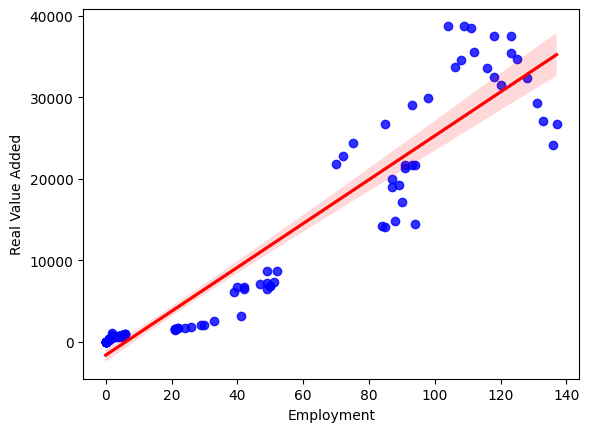

In [724]:
# relationship between employee # and overall gross product
sns.regplot(x = overall_business['Employment'], y = overall_business['Real Value Added'], scatter_kws = {'color': 'blue'}, line_kws = {'color': 'red'})

<Axes: xlabel='Compensation', ylabel='Real Value Added'>

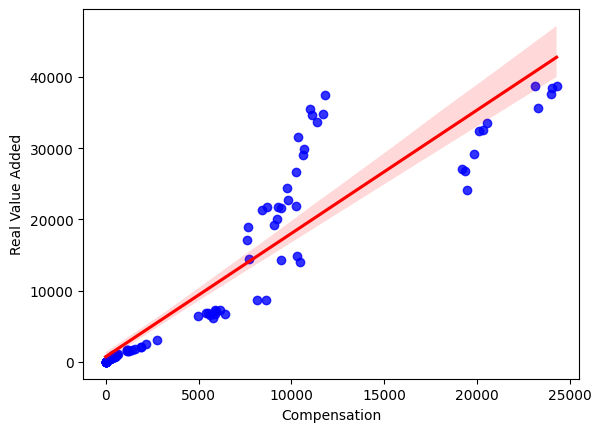

In [725]:
# relationship between employment and compensation
sns.regplot(x = overall_business['Compensation'], y = overall_business['Real Value Added'], scatter_kws = {'color': 'blue'}, line_kws = {'color': 'red'})

<Axes: xlabel='Employment', ylabel='Real Gross Output'>

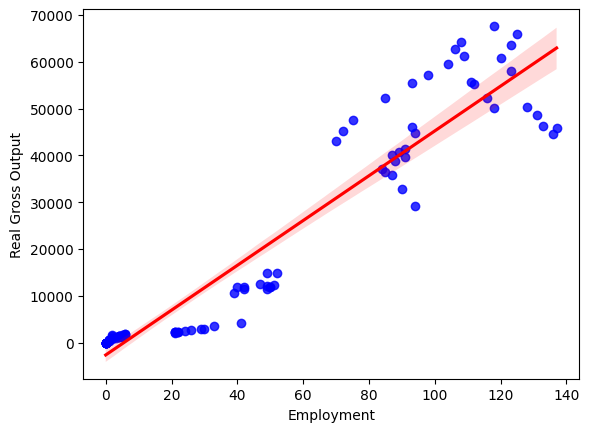

In [726]:
# relationship between employment and real gross product
sns.regplot(x = overall_business['Employment'], y = overall_business['Real Gross Output'], scatter_kws = {'color': 'blue'}, line_kws = {'color': 'red'})

<Axes: xlabel='Compensation', ylabel='Real Gross Output'>

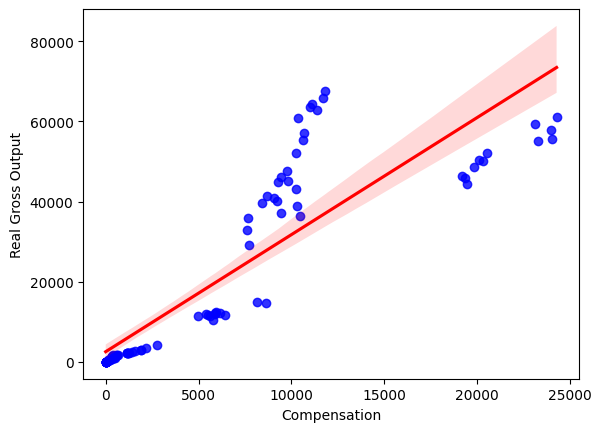

In [727]:
# relationship between compensation and real gross output
sns.regplot(x = overall_business['Compensation'], y = overall_business['Real Gross Output'], scatter_kws = {'color': 'blue'}, line_kws = {'color': 'red'})

## Machine Learning Task - "How Much Product Are We Expected To Generate By A 1% Increase In Compensation?"

       Variable      VIF
0          Year  1.77835
1  Compensation  1.77835


(np.float64(0.21978255296106491), 0.996104737258489)

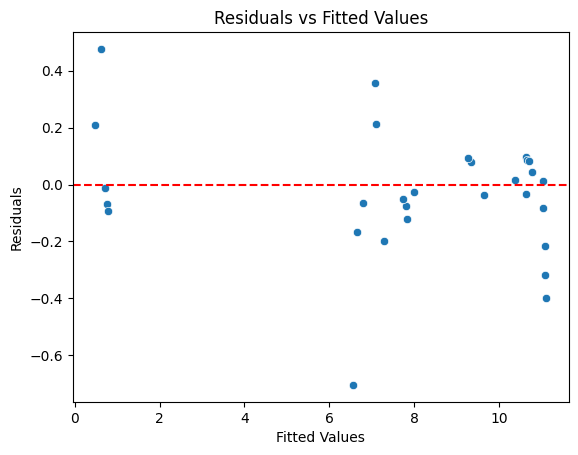

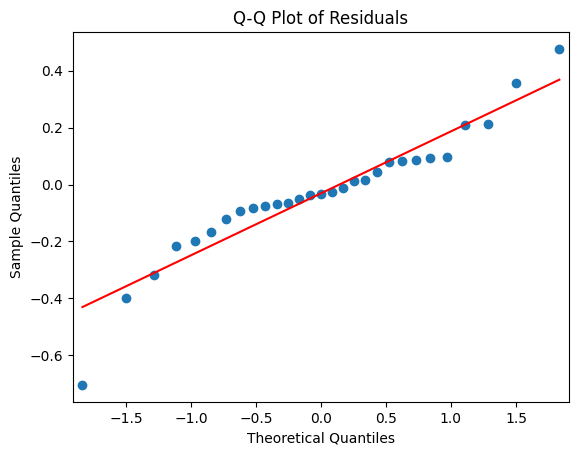

In [728]:
# reset index
overall_business = overall_business.reset_index()

# target and feature datasets
X = overall_business.drop(['Real Value Added', 'Employment', 'Gross Output', 'Value Added Price Index', 'Gross Output Price Index', 'Value Added', 'Real Gross Output', 'index'], axis = 1)
y = np.log(overall_business['Real Gross Output'])

# one hot encoded industry 
X_encoded = pd.get_dummies(X, columns = ['Industry'], drop_first = True)
X = X.drop('Industry', axis = 1)

# checking multicollinearity
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

# train test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = .3, random_state = 42)

# creating linear regression model
model_business = LinearRegression()
model_business.fit(X_train, y_train)
y_pred = model_business.predict(X_test)

# Calculating MSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
r2 = r2_score(y_test, y_pred)

# residuals vs fitted values plot
residuals = y_test - y_pred

sns.scatterplot(x = y_pred, y = residuals) # must check for linearity, homoskedasticity, and normality
plt.axhline(y = 0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
#plt.show()

# Q-Q Plot
sm.qqplot(residuals, line = 's')
plt.title("Q-Q Plot of Residuals")
#plt.show()

rmse, r2

In [729]:
# baseline model
y_pred_mean = np.mean(y_train)

y_pred_baseline = np.repeat(y_pred_mean, len(y_test))

rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

r2 = r2_score(y_test, y_pred_baseline)
rmse, r2

(np.float64(3.5556045255416673), -0.01947652483586304)

In [730]:
# checking for overfitting
y_pred_train = model_business.predict(X_train)
y_pred_test = model_business.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

rmse_train, rmse_test

(np.float64(0.22689314962939083), np.float64(0.21978255296106491))

In [731]:
# examining features
coefficients = model_business.coef_
intercept = model_business.intercept_

coef_dict = pd.Series(model_business.coef_, index = X_encoded.columns).to_dict()
coef_dict['Intercept'] = model_business.intercept_

coef_dict


{'Year': 0.027512052992456106,
 'Compensation': 3.496230182798028e-05,
 'Industry_Educational services, health care, and social assistance': 1.1497363683652206,
 'Industry_Information': 3.970355515049654,
 'Industry_Manufacturing': 3.402340945831692,
 'Industry_Professional and business services': 2.502745319825772,
 'Industry_Transportation and warehousing': 0.5332933351637572,
 'Industry_Utilities': -6.045163539533434,
 'Industry_Wholesale trade': 3.561225289723549,
 'Intercept': np.float64(-48.823914152909126)}